# **1. Mistake During Data Entry**

In [ ]:
import pandas as pd
import numpy as np

***Example 1***

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DTS/Data/data1.csv', sep = ";")
data.head()

,Name,Test Result
0,Mike,Pass
1,Olivia,Failed
2,Mita,Failed
3,Dodi,Pass
4,Alyssa,Pas


**Deteksi**

In [ ]:
data.groupby("Test Result").count()

,Name
Test Result,
Fail,1
Failed,3
Pas,1
Pass,4
pass,1


**Solusi**

In [ ]:
#Replace Data
data["Test Result"] = data["Test Result"].replace("Failed","Fail")
data["Test Result"] = data["Test Result"].replace("Pas","Pass")
data["Test Result"] = data["Test Result"].replace("pass","Pass")

In [ ]:
data

,Name,Test Result
0,Mike,Pass
1,Olivia,Fail
2,Mita,Fail
3,Dodi,Pass
4,Alyssa,Pass
5,Andi,Pass
6,Edo,Fail
7,Alicia,Pass
8,Jason,Fail
9,Mattew,Pass


In [ ]:
data.groupby("Test Result").count()

,Name
Test Result,
Fail,4
Pass,6


***Example 2***

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DTS/Data/data2.csv', sep = ";")
data

,Name,University
0,Mike,UISI
1,Olivia,ITS
2,Mita,iTs
3,Dodi,UISI
4,Alyssa,UNS
5,Andi,UNS
6,Edo,Uns
7,Alicia,uns
8,Jason,UISI
9,Mattew,Uisi


**Deteksi**

In [ ]:
data.groupby("University").count()

,Name
University,
ITS,1
UISI,2
UISI,1
UNS,1
UNS,1
Uisi,1
Uns,1
iTs,1
uns,1


**Solusi**

In [ ]:
for i in range(0,data.shape[0]):
    data.iloc[i,1] = data.iloc[i,1].upper()

In [ ]:
data

,Name,University
0,Mike,UISI
1,Olivia,ITS
2,Mita,ITS
3,Dodi,UISI
4,Alyssa,UNS
5,Andi,UNS
6,Edo,UNS
7,Alicia,UNS
8,Jason,UISI
9,Mattew,UISI


In [ ]:
data.groupby("University").count()

,Name
University,
ITS,2
UISI,3
UISI,1
UNS,3
UNS,1


# **2. Redundant Whitespace**

*# Using Previous Result*

In [ ]:
for i in range(0,data.shape[0]):
    data.iloc[i,1] = data.iloc[i,1].strip()

In [ ]:
data

,Name,University
0,Mike,UISI
1,Olivia,ITS
2,Mita,ITS
3,Dodi,UISI
4,Alyssa,UNS
5,Andi,UNS
6,Edo,UNS
7,Alicia,UNS
8,Jason,UISI
9,Mattew,UISI


In [ ]:
data.groupby("University").count()

,Name
University,
ITS,2
UISI,4
UNS,4


**Solusi**

In [ ]:
# Hilangkan spasi berlebih (depan, belakang, dan ganda di tengah)
data = data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
data = data.apply(lambda x: x.str.replace(r'\s+', ' ', regex=True) if x.dtype == "object" else x)

In [ ]:
data.head()

,ID,Nama,Divisi,Jabatan,Gaji,Kota,Email
0,1,Winda Sari,HRD,Analis,7.000.00O,Depok,windasari@gmail. com
1,2,Bagus Prakoso,Produksi,Kepala Bagian,"7,500,000",Maalaang,bagusprakoso@gmail. com
2,3,Dewi Anggraini,IT,Admin,8.000.000,Bekaasi,dewianggraini@gmail. com
3,4,Dewi Anggraini,operasional,Manager,8000000,Depok,dewianggraini@gmail. com
4,5,NaN,it,Kepala Bagian,7500000,Malang,gilangsaputra@gmail. com


# **3. Impossible Value**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DTS/Data/data3.csv')
data

,Name,Age
0,Mike,-30
1,Olivia,50
2,Mita,97
3,Dodi,30
4,Alyssa,25
5,Andi,15
6,Edo,3
7,Alicia,23
8,Jason,3000
9,Mattew,10


# **4. Missing value**

**Deteksi**

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DTS/Data/data_perusahaan_kotor.csv')
data.head(10)

,ID,Nama,Divisi,Jabatan,Gaji,Kota,Email
0,1,Winda Sari,HRD,Analis,7.000.00O,Depok,windasari@gmail. com
1,2,Bagus Prakoso,Produksi,Kepala Bagian,"7,500,000",Maalaang,bagusprakoso@gmail. com
2,3,Dewi Anggraini,IT,Admin,8.000.000,Bekaasi,dewianggraini@gmail. com
3,4,Dewi Anggraini,operasional,Manager,8000000,Depok,dewianggraini@gmail. com
4,5,NaN,it,Kepala Bagian,7500000,Malang,gilangsaputra@gmail. com
5,6,NaN,Operasional,Supervisor,"7,500,000",Bandung,tasyamaharani@gmail. com
6,7,Arifin Hidayat,Logistik,Admin,8000000,Malang,arifinhidayat@gmail. com
7,8,Novi Handayani,Marketing,Engineer,7500000,Depok,novihandayani@gmail. com
8,9,Eka Firmansyah,Produksi,Engineer,8000000,Surabaya,ekafirmansyah@@gmail. com
9,10,Andika Prasetia,Operasional,Supervisor,7000000,Bandung,andikaprasetia@gmail. com


In [ ]:
# Cek jumlah missing value per kolom
data.isnull().sum()

,0
ID,0
Nama,4
Divisi,0
Jabatan,0
Gaji,6
Kota,0
Email,0


In [ ]:
# tampilkan baris yang mengandung missing value
data[data.isnull().any(axis=1)]

,ID,Nama,Divisi,Jabatan,Gaji,Kota,Email
4,5,NaN,it,Kepala Bagian,7500000,Malang,gilangsaputra@gmail. com
5,6,NaN,Operasional,Supervisor,"7,500,000",Bandung,tasyamaharani@gmail. com
12,13,NaN,Finance,Engineer,7.000.00O,Bandung,lilispurnama@gmail. com
13,14,Budi Setiawan,marketing,Staff,NaN,Depok,budisetiawan@@gmail. com
28,29,NaN,marketing,Admin,NaN,Depok,donipratama@@gmail. com
29,30,Novi Handayani,IT,Analis,NaN,Bandung,novihandayani@gmail. com
36,37,Ratna Dewi,HRD,Kepala Bagian,NaN,Bekasi,ratnadewi@gmail. com
37,38,Hendra Wijaya,HRD,Supervisor,NaN,Bekasi,hendrawijaya@gmail. com
46,47,Dewi Anggraini,R&D,Analis,NaN,Bekasi,dewianggraini@gmail. com


<Axes: >

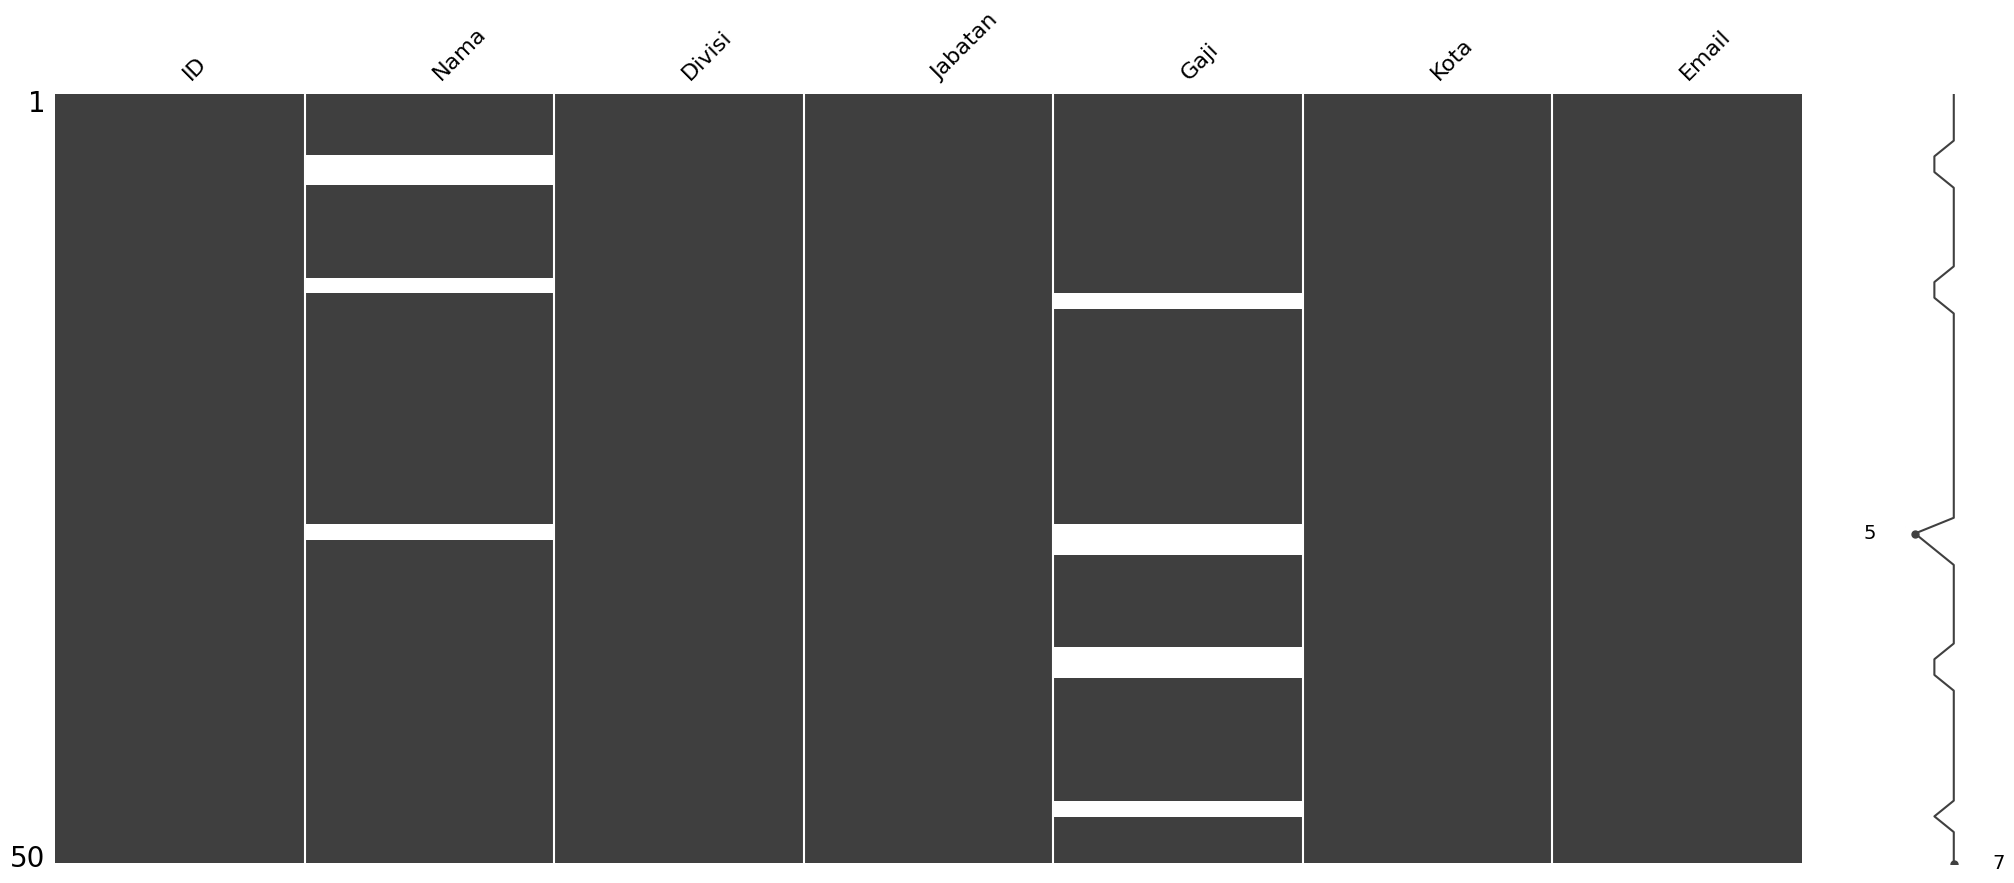

In [ ]:
!pip install missingno
import missingno as msno

msno.matrix(data)


**Solusi**

1. Omit the Value

In [ ]:
data_drop_row = data.dropna()
data_drop_row.head(10)

,ID,Nama,Divisi,Jabatan,Gaji,Kota,Email
0,1,Winda Sari,HRD,Analis,7.000.00O,Depok,windasari@gmail. com
1,2,Bagus Prakoso,Produksi,Kepala Bagian,"7,500,000",Maalaang,bagusprakoso@gmail. com
2,3,Dewi Anggraini,IT,Admin,8.000.000,Bekaasi,dewianggraini@gmail. com
3,4,Dewi Anggraini,operasional,Manager,8000000,Depok,dewianggraini@gmail. com
6,7,Arifin Hidayat,Logistik,Admin,8000000,Malang,arifinhidayat@gmail. com
7,8,Novi Handayani,Marketing,Engineer,7500000,Depok,novihandayani@gmail. com
8,9,Eka Firmansyah,Produksi,Engineer,8000000,Surabaya,ekafirmansyah@@gmail. com
9,10,Andika Prasetia,Operasional,Supervisor,7000000,Bandung,andikaprasetia@gmail. com
10,11,Eko Setiawan,Operasional,Kepala Bagian,7.000.00O,Malang,ekosetiawan@gmail. com
11,12,Fauzan Rahman,Operasional,Engineer,7500000,Jakarta,fauzanrahman@gmail. com


In [ ]:
data_drop_col = data.dropna(axis=1)
data_drop_col.head(10)

,ID,Divisi,Jabatan,Kota,Email
0,1,HRD,Analis,Depok,windasari@gmail. com
1,2,Produksi,Kepala Bagian,Maalaang,bagusprakoso@gmail. com
2,3,IT,Admin,Bekaasi,dewianggraini@gmail. com
3,4,operasional,Manager,Depok,dewianggraini@gmail. com
4,5,it,Kepala Bagian,Malang,gilangsaputra@gmail. com
5,6,Operasional,Supervisor,Bandung,tasyamaharani@gmail. com
6,7,Logistik,Admin,Malang,arifinhidayat@gmail. com
7,8,Marketing,Engineer,Depok,novihandayani@gmail. com
8,9,Produksi,Engineer,Surabaya,ekafirmansyah@@gmail. com
9,10,Operasional,Supervisor,Bandung,andikaprasetia@gmail. com


2. Set value to NULL

In [ ]:
data_null = data.replace(["it", 0], np.nan)
data_null.head(10)

,ID,Nama,Divisi,Jabatan,Gaji,Kota,Email
0,1,Winda Sari,HRD,Analis,7.000.00O,Depok,windasari@gmail. com
1,2,Bagus Prakoso,Produksi,Kepala Bagian,"7,500,000",Maalaang,bagusprakoso@gmail. com
2,3,Dewi Anggraini,IT,Admin,8.000.000,Bekaasi,dewianggraini@gmail. com
3,4,Dewi Anggraini,operasional,Manager,8000000,Depok,dewianggraini@gmail. com
4,5,NaN,NaN,Kepala Bagian,7500000,Malang,gilangsaputra@gmail. com
5,6,NaN,Operasional,Supervisor,"7,500,000",Bandung,tasyamaharani@gmail. com
6,7,Arifin Hidayat,Logistik,Admin,8000000,Malang,arifinhidayat@gmail. com
7,8,Novi Handayani,Marketing,Engineer,7500000,Depok,novihandayani@gmail. com
8,9,Eka Firmansyah,Produksi,Engineer,8000000,Surabaya,ekafirmansyah@@gmail. com
9,10,Andika Prasetia,Operasional,Supervisor,7000000,Bandung,andikaprasetia@gmail. com


3. Impute a Static Value to 0 or The Mean

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DTS/Data/data_mean.csv')
data

,nilai_math,nilai_english,nilai_science
0,80.0,NaN,88.0
1,NaN,75.0,NaN
2,90.0,70.0,92.0
3,85.0,NaN,85.0
4,NaN,85.0,90.0
5,88.0,90.0,NaN
6,92.0,NaN,89.0
7,NaN,88.0,87.0
8,75.0,82.0,NaN
9,78.0,80.0,84.0


In [ ]:
data_fill0 = data.fillna(0)
data_fill0

,nilai_math,nilai_english,nilai_science
0,80.0,0.0,88.0
1,0.0,75.0,0.0
2,90.0,70.0,92.0
3,85.0,0.0,85.0
4,0.0,85.0,90.0
5,88.0,90.0,0.0
6,92.0,0.0,89.0
7,0.0,88.0,87.0
8,75.0,82.0,0.0
9,78.0,80.0,84.0


In [ ]:
mean_math = data["nilai_math"].mean()
data["nilai_math"] = data["nilai_math"].fillna(mean_math)

In [ ]:
data

,nilai_math,nilai_english,nilai_science
0,80.0,NaN,88.0
1,84.0,75.0,NaN
2,90.0,70.0,92.0
3,85.0,NaN,85.0
4,84.0,85.0,90.0
5,88.0,90.0,NaN
6,92.0,NaN,89.0
7,84.0,88.0,87.0
8,75.0,82.0,NaN
9,78.0,80.0,84.0


# **5. Outlier**

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DTS/Data/data3.csv')
data

,Name,Age
0,Mike,-30
1,Olivia,50
2,Mita,97
3,Dodi,30
4,Alyssa,25
5,Andi,15
6,Edo,3
7,Alicia,23
8,Jason,3000
9,Mattew,10


Text(0, 0.5, 'Frequency')

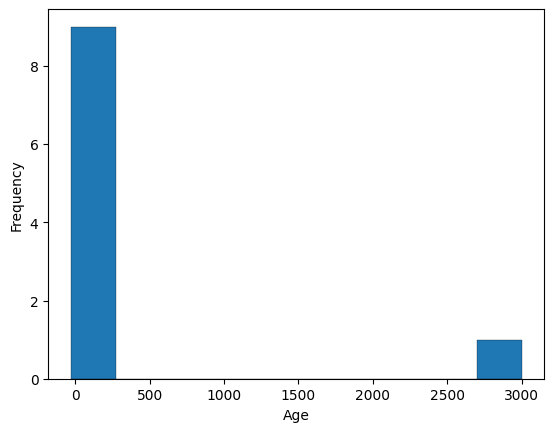

In [ ]:
plt.hist(data["Age"], edgecolor='black', linewidth=0.2)
plt.xlabel('Age')
plt.ylabel('Frequency')

{'whiskers': [<matplotlib.lines.Line2D at 0x78d37954deb0>,
 'caps': [<matplotlib.lines.Line2D at 0x78d37954e2d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78d37954dc40>],
 'medians': [<matplotlib.lines.Line2D at 0x78d37954e900>],
 'fliers': [<matplotlib.lines.Line2D at 0x78d37954ec00>],
 'means': []}

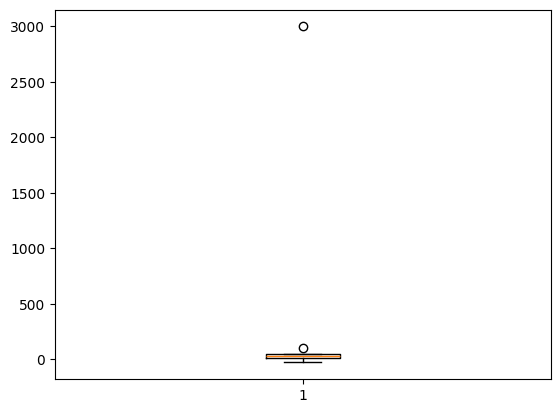

In [ ]:
plt.boxplot(data["Age"])